In [ ]:
!pip install onnx
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 22.8 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim

from torch.nn.utils.fusion import fuse_conv_bn_eval

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import onnx

import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime
from time import time
import copy

In [ ]:


def compute_l1_norm(model):
  l1 = 0
  for name, param in model.named_parameters():
    # Check if the parameter name contains 'weight' and does NOT contain 'bias'
    # The 'weight' check is often redundant if you skip 'bias', but good practice.
    # The key is to check for 'bias' in the name and skip it.
    if 'bias' not in name:
      l1 += torch.sum(torch.abs(param))

  return l1



In [ ]:
def get_loaders(batch_size=64, num_workers=2, normalize=True):
    # Statistiche CIFAR-10 standard
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2470, 0.2435, 0.2616)

    if normalize:
      train_tf = transforms.Compose([
          transforms.RandomCrop(32, padding=4),       # augmentation fondamentale
          transforms.RandomHorizontalFlip(),
          transforms.ToTensor(),
          transforms.Normalize(mean, std),
      ])
      test_tf = transforms.Compose([
          transforms.ToTensor(),
          transforms.Normalize(mean, std),
      ])
    else:
      train_tf = transforms.Compose([
          transforms.RandomCrop(32, padding=4),       # augmentation fondamentale
          transforms.RandomHorizontalFlip(),
          transforms.ToTensor(),
      ])
      test_tf = transforms.Compose([
          transforms.ToTensor(),
      ])

    train_ds = datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_tf)
    test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, test_loader

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, l1_weight=0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)

        if l1_weight > 0:
          l1_reg = compute_l1_norm(model)
          loss += l1_weight * l1_reg

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total

In [ ]:
def training_loop(model, train_loader, test_loader, epochs=100, batch_size=128, lr=1e-3, l1_weight=0, torch_path="best_model.pth"):
    DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Device: {DEVICE}")
    model = model.to(DEVICE)

    train_loader, test_loader = get_loaders(batch_size=batch_size)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Cosine annealing: abbassa lr dolcemente fino a quasi 0
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Conta parametri
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parameters: {n_params:,}\n")

    train_losses = []
    test_losses  = []
    best_acc = 0.0
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE, l1_weight=l1_weight)
        test_loss,  test_acc  = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step()

        if l1_weight > 0:
            l1_reg = compute_l1_norm(model)
            print(f"L1: {l1_reg.item()}")

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), torch_path)

        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"train loss {train_loss:.3f} acc {train_acc*100:.1f}% | "
              f"test loss {test_loss:.3f} acc {test_acc*100:.1f}% | "
              f"best {best_acc*100:.1f}%")
        train_losses.append(train_loss)
        test_losses.append(test_loss)

    print(f"\nBest test accuracy: {best_acc*100:.2f}%")

    return model, train_losses, test_losses

In [ ]:
# with batch norm before activation function
def make_cnn_tiny(in_ch, in_dim, width=16, linear_size=256, act_fun=nn.GELU, act_kwargs={}):
    model = nn.Sequential(
        nn.Conv2d(in_ch, width, 3, stride=2, padding=0),  # width x 15 x 15
        nn.BatchNorm2d(width),
        act_fun(**act_kwargs),
        nn.Conv2d(width, 2*width, 3, stride=2, padding=0),  # 2*width x 7 x 7
        nn.BatchNorm2d(2*width),
        act_fun(**act_kwargs),
        nn.Conv2d(2*width, 4*width, 3, stride=2, padding=0),  # 4*width x 3 x 3
        nn.BatchNorm2d(4 * width),
        act_fun(),
        nn.Flatten(),
        # nn.Linear((in_dim//8) * (in_dim//8) * 4 * width, linear_size),
        nn.Linear(3 * 3 * 4 * width, linear_size),
        act_fun(**act_kwargs),
        nn.Linear(linear_size,10)
    )
    return model

In [ ]:


def fuse_bn_recursively_sequential(model, layers=None):
    if layers is None:
        layers = []

    # We need to look ahead or keep track of the previous conv
    it = list(model.named_children())
    i = 0
    while i < len(it):
        name, child = it[i]

        # Check for Conv-BN pair
        if isinstance(child, nn.Conv2d) and (i + 1 < len(it)) and isinstance(it[i+1][1], nn.BatchNorm2d):
            print(f"Fusing {it[i+1][0]} into {name}")
            fused_conv = fuse_conv_bn_eval(child, it[i+1][1])
            layers.append(fused_conv)
            i += 2  # Skip both the Conv and the BN

        elif len(list(child.children())) > 0:
            # Recurse without re-wrapping in Sequential yet
            fuse_bn_recursively_sequential(child, layers)
            i += 1

        else:
            # It's a standalone layer (GELU, Linear, Flatten, or a BN with no Conv)
            layers.append(child)
            i += 1

    return nn.Sequential(*layers)

In [ ]:
def get_normalization_layer(mean, std):
  # CIFAR-10 means/stds
  mean = torch.tensor(mean)
  std = torch.tensor(std)

  # Create a BN layer
  norm_layer = nn.BatchNorm2d(3)

  # Set parameters
  norm_layer.running_mean.copy_(mean)
  norm_layer.running_var.copy_(std**2) # BN uses variance
  norm_layer.weight.data.fill_(1.0)
  norm_layer.bias.data.fill_(0.0)
  norm_layer.eps = 1e-12 # Minimal epsilon for stability

  norm_layer.eval() # Vital: lock it so it doesn't update
  return norm_layer

In [ ]:
def add_kernel_shape_attribute(onnx_path):
    model = onnx.load(onnx_path)

    for node in model.graph.node:
        if node.op_type == "Conv":
            has_kernel = any(attr.name == "kernel_shape" for attr in node.attribute)
            if not has_kernel:
                # find weight tensor
                weight_name = node.input[1]
                for init in model.graph.initializer:
                    if init.name == weight_name:
                        shape = init.dims
                        kernel_shape = shape[2:]  # (kH, kW)

                        attr = onnx.helper.make_attribute("kernel_shape", kernel_shape)
                        node.attribute.append(attr)

    model = onnx.shape_inference.infer_shapes(model)
    onnx.save(model, onnx_path)

In [ ]:
def export_onnx(model, onnx_path, mean=None, std=None):
    if mean is None:
        mean = (0.4914, 0.4822, 0.4465)
    if std is None:
        std  = (0.2470, 0.2435, 0.2616)

    model.eval()
    model_norm = nn.Sequential(get_normalization_layer(mean, std), model)
    model_seq = fuse_bn_recursively_sequential(model_norm)

    dummy_input = torch.randn(1, 3, 32, 32)

    torch.onnx.export(
        model_seq.to('cpu'),
        dummy_input,
        onnx_path,
        export_params=True,       # Store the trained parameter weights inside the model file
        opset_version=20,          # The ONNX version to export to
        do_constant_folding=True,  # Whether to execute constant folding for optimization
        input_names=['input'],     # The model's input names
        output_names=['output'],    # The model's output names
        external_data=False
    )

    # sometimes, conv nodes get saved without kernel_shape attribute, but onnx2pytorch
    # requires that attribute for correct parsing, so add it manually and save it back to file
    add_kernel_shape_attribute(onnx_path)

    print(f"Model successfully exported to {onnx_path}")

In [ ]:
EPOCHS     = 120
BATCH_SIZE = 128
LR         = 1e-3
WIDTH      = 8
l1_weight  = 0.
torch_path = f"best_model_bn_{WIDTH}.pth"
onnx_path  = f"best_model_bn_{WIDTH}.onnx"
model      = make_cnn_tiny(3, 32, width=WIDTH, linear_size=256, act_fun=nn.GELU)
train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model, train_losses, test_losses = training_loop(model, train_loader, test_loader, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, l1_weight=l1_weight, torch_path=torch_path)

export_onnx(model, onnx_path)

Device: cuda
Parameters: 82,698

Epoch   1/120 | train loss 1.640 acc 39.8% | test loss 1.368 acc 50.0% | best 50.0%
Epoch   2/120 | train loss 1.412 acc 48.7% | test loss 1.263 acc 54.0% | best 54.0%
Epoch   3/120 | train loss 1.311 acc 52.5% | test loss 1.180 acc 57.0% | best 57.0%
Epoch   4/120 | train loss 1.235 acc 55.7% | test loss 1.134 acc 59.2% | best 59.2%
Epoch   5/120 | train loss 1.172 acc 58.1% | test loss 1.089 acc 60.5% | best 60.5%
Epoch   6/120 | train loss 1.126 acc 59.7% | test loss 1.061 acc 62.5% | best 62.5%
Epoch   7/120 | train loss 1.091 acc 60.9% | test loss 1.013 acc 63.7% | best 63.7%
Epoch   8/120 | train loss 1.065 acc 62.2% | test loss 1.008 acc 63.8% | best 63.8%
Epoch   9/120 | train loss 1.035 acc 63.0% | test loss 0.993 acc 64.6% | best 64.6%
Epoch  10/120 | train loss 1.022 acc 63.9% | test loss 0.964 acc 65.8% | best 65.8%
Epoch  11/120 | train loss 0.999 acc 64.5% | test loss 0.955 acc 66.0% | best 66.0%
Epoch  12/120 | train loss 0.983 acc 64.8% 

/tmp/ipykernel_3242/866972806.py:13: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(
W0408 16:44:10.129000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0408 16:44:10.131000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0408 16:44:10.134000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). 

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Model successfully exported to best_model_bn_8.onnx


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


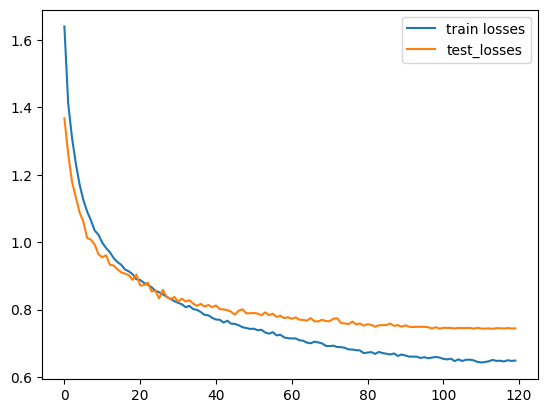

In [ ]:
plt.plot(train_losses, label="train losses")
plt.plot(test_losses, label="test_losses")
plt.legend()
plt.show()

In [ ]:
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-3
WIDTH      = 8
l1_weight  = 2e-5
torch_path = f"best_model_bn_{WIDTH}_{l1_weight}l1.pth"
onnx_path  = f"best_model_bn_{WIDTH}_{l1_weight}l1.onnx"
model      = make_cnn_tiny(3, 32, width=WIDTH, linear_size=256, act_fun=nn.GELU)
state_dict = torch.load(f"best_model_bn_{WIDTH}.pth", weights_only=True)
model.load_state_dict(state_dict)

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model, train_losses, test_losses = training_loop(model, train_loader, test_loader, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, l1_weight=l1_weight, torch_path=torch_path)

export_onnx(model, onnx_path)

Device: cuda
Parameters: 82,698

L1: 9676.2548828125
Epoch   1/100 | train loss 0.910 acc 74.8% | test loss 0.782 acc 73.8% | best 73.8%
L1: 9535.345703125
Epoch   2/100 | train loss 0.912 acc 74.7% | test loss 0.785 acc 73.3% | best 73.8%
L1: 9421.80078125
Epoch   3/100 | train loss 0.911 acc 74.5% | test loss 0.767 acc 73.8% | best 73.8%
L1: 9307.798828125
Epoch   4/100 | train loss 0.907 acc 74.5% | test loss 0.765 acc 73.9% | best 73.9%
L1: 9201.56640625
Epoch   5/100 | train loss 0.902 acc 74.6% | test loss 0.775 acc 73.3% | best 73.9%
L1: 9107.56640625
Epoch   6/100 | train loss 0.903 acc 74.5% | test loss 0.772 acc 73.9% | best 73.9%
L1: 9019.123046875
Epoch   7/100 | train loss 0.900 acc 74.5% | test loss 0.784 acc 73.9% | best 73.9%
L1: 8932.2802734375
Epoch   8/100 | train loss 0.899 acc 74.7% | test loss 0.779 acc 73.6% | best 73.9%
L1: 8851.62109375
Epoch   9/100 | train loss 0.899 acc 74.6% | test loss 0.770 acc 73.5% | best 73.9%
L1: 8772.6826171875
Epoch  10/100 | train 

/tmp/ipykernel_3242/866972806.py:13: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(
W0408 17:18:37.941000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0408 17:18:37.943000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0408 17:18:37.945000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). 

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Model successfully exported to best_model_bn_8_2e-05l1.onnx


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


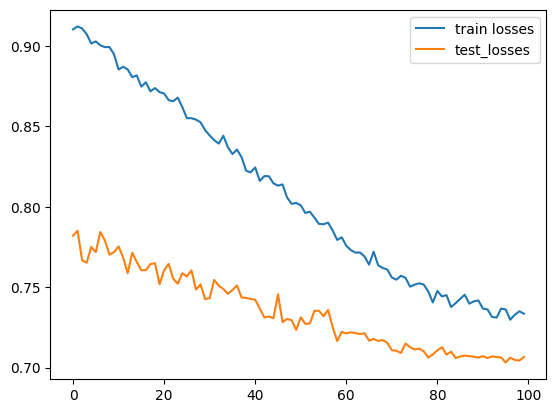

In [ ]:


plt.plot(train_losses, label="train losses")
plt.plot(test_losses, label="test_losses")
plt.legend()
plt.show()



In [ ]:
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-3
WIDTH      = 8
l1_weight  = 1e-4
torch_path = f"best_model_bn_{WIDTH}_{l1_weight}l1.pth"
onnx_path  = f"best_model_bn_{WIDTH}_{l1_weight}l1.onnx"
model      = make_cnn_tiny(3, 32, width=WIDTH, linear_size=256, act_fun=nn.GELU)
state_dict = torch.load(f"best_model_bn_{WIDTH}_{2e-5}l1.pth", weights_only=True)
model.load_state_dict(state_dict)

train_loader, test_loader = get_loaders(batch_size=BATCH_SIZE)

model, train_losses, test_losses = training_loop(model, train_loader, test_loader, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, l1_weight=l1_weight, torch_path=torch_path)

export_onnx(model, onnx_path)

Device: cuda
Parameters: 82,698

L1: 6474.33056640625
Epoch   1/100 | train loss 1.344 acc 76.2% | test loss 0.758 acc 74.2% | best 74.2%
L1: 6096.57666015625
Epoch   2/100 | train loss 1.315 acc 75.8% | test loss 0.740 acc 75.1% | best 75.1%
L1: 5764.91162109375
Epoch   3/100 | train loss 1.293 acc 75.1% | test loss 0.740 acc 75.1% | best 75.1%
L1: 5488.64404296875
Epoch   4/100 | train loss 1.268 acc 75.1% | test loss 0.737 acc 74.9% | best 75.1%
L1: 5243.7392578125
Epoch   5/100 | train loss 1.252 acc 74.7% | test loss 0.749 acc 74.2% | best 75.1%
L1: 5029.267578125
Epoch   6/100 | train loss 1.233 acc 74.6% | test loss 0.750 acc 74.5% | best 75.1%
L1: 4842.7041015625
Epoch   7/100 | train loss 1.217 acc 74.5% | test loss 0.746 acc 74.2% | best 75.1%
L1: 4672.74462890625
Epoch   8/100 | train loss 1.209 acc 74.1% | test loss 0.757 acc 74.1% | best 75.1%
L1: 4529.3193359375
Epoch   9/100 | train loss 1.193 acc 74.4% | test loss 0.750 acc 74.3% | best 75.1%
L1: 4402.41845703125
Epoch 

/tmp/ipykernel_3242/866972806.py:13: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(
W0408 17:52:51.404000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0408 17:52:51.406000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0408 17:52:51.407000 3242 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). 

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Model successfully exported to best_model_bn_8_0.0001l1.onnx


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


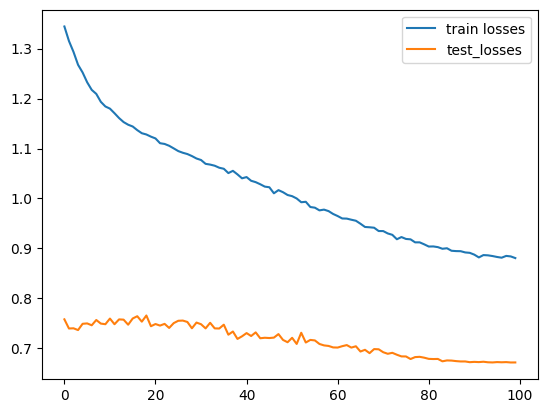

In [ ]:
plt.plot(train_losses, label="train losses")
plt.plot(test_losses, label="test_losses")
plt.legend()
plt.show()